# Solshade JOSS Plots

This notebook reproduces the plots for the JOSS paper

In [1]:
from pathlib import Path

import cmasher as cmr
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import NullFormatter
from pyproj import Transformer

from solshade.irradiance import compute_energy_metrics, compute_flux_timeseries
from solshade.solar import compute_solar_ephem
from solshade.terrain import compute_hillshade, compute_horizon_map, compute_slope_aspect_normals, load_dem
from solshade.utils import parse_iso_utc
from solshade.viz import (
    _get_extent,
    plot_day_of_peak,
    plot_dem,
    plot_peak_energy,
    plot_total_energy,
)

plt.rcParams["font.family"] = "serif"

## Download test data

In [2]:
!mkdir -p data/tifs
!wget -nc -O data/tifs/MARS.tif https://raw.githubusercontent.com/amanchokshi/solshade/main/tests/data/MARS.tif

File ‘data/tifs/MARS.tif’ already there; not retrieving.


## Load DEM

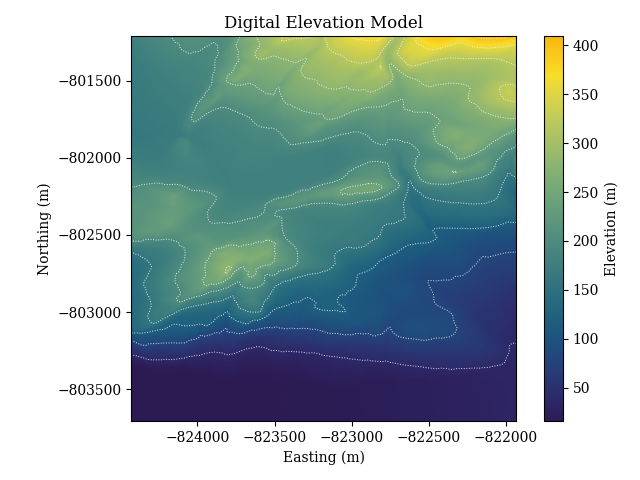

In [3]:
%matplotlib widget

DEM_PATH = Path("data/tifs/MARS.tif")
dem = load_dem(DEM_PATH)

plot_dem(dem)
plt.tight_layout()
plt.show()

## Compute Slope, Aspect, Normals, Hillshade, Horizon

In [4]:
slope, aspect, normals = compute_slope_aspect_normals(dem)
hillshade = compute_hillshade(slope, aspect, azimuth_deg=315, altitude_deg=45)
horizon = compute_horizon_map(dem, n_directions=360, max_distance=2000, step=20, chunk_size=32, n_jobs=-1)

Output()

## Compute Solar Ephemerides and Flux Time Series

In [5]:
lat, lon = 79.417183, -90.767350

ny, nx = dem.shape[-2:]
cy, cx = ny // 2, nx // 2
x, y = dem.rio.transform() * (cx + 0.5, cy + 0.5)
if dem.rio.crs and dem.rio.crs.to_epsg() != 4326:
    transformer = Transformer.from_crs(dem.rio.crs, "EPSG:4326", always_xy=True)
    lon_derived, lat_derived = transformer.transform(x, y)
else:
    lon_derived, lat_derived = x, y
lat_val: float = float(lat_derived)
lon_val: float = float(lon_derived)


times, alt, az, au, enu = compute_solar_ephem(
    lat=lat, lon=lon, startutc=parse_iso_utc("2025-01-01T00:00:00Z"), stoputc=parse_iso_utc("2026-01-01T00:00:00Z")
)
flux = compute_flux_timeseries(horizon, alt, az, au, enu, normals, times, batch_size=512, n_jobs=-1)

Output()

## Compute Energy Metrics

In [6]:
daily, total, peak, daypeak = compute_energy_metrics(flux)

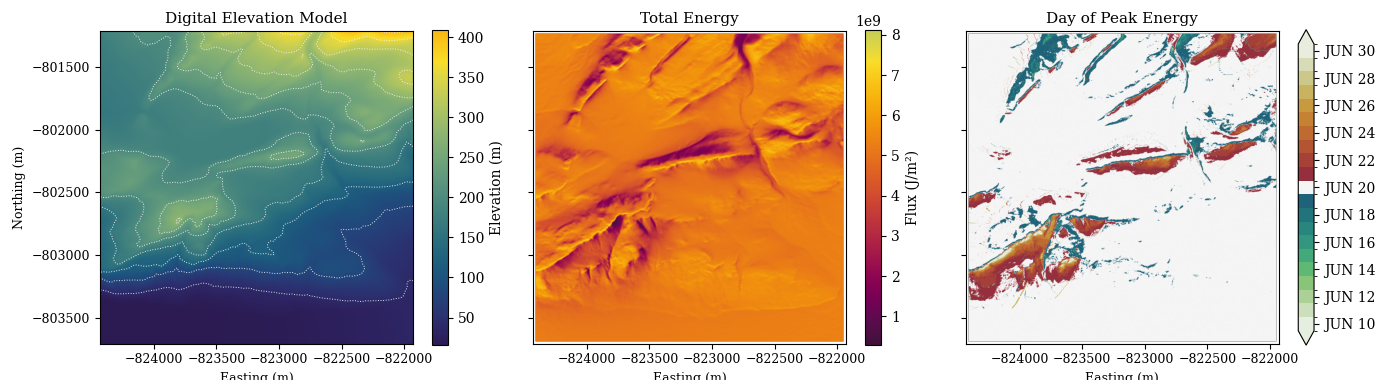

In [7]:
%matplotlib widget

fig, axs = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)

plot_dem(dem, axs[0])

plot_total_energy(total, axs[1])

daily_iso = np.datetime_as_string(daily.time.astype("datetime64[s]"), unit="s", timezone="UTC").tolist()  # type: ignore
daily_iso = np.array([s.rstrip("Z") for s in daily_iso], dtype="datetime64[s]")
plot_day_of_peak(daypeak, daily_iso, sigma=9, ax=axs[2])

axs[1].set_ylabel("")
axs[2].set_ylabel("")

# Example titles and labels
titles = ["Digital Elevation Model", "Total Energy", "Day of Peak Energy"]
xlabels = ["Easting (m)", "Easting (m)", "Easting (m)"]
ylabels = ["Northing (m)", "", ""]  # Only first one gets a ylabel
cbar_labels = ["Elevation (m)", "Flux (J/m²)", "Day of Year"]

# Apply titles, axis labels, tick font sizes
for ax, title, xlabel, ylabel in zip(axs, titles, xlabels, ylabels):
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(xlabel, fontsize=9)
    if ylabel:  # only set if non-empty
        ax.set_ylabel(ylabel, fontsize=9)
    ax.tick_params(axis="both", labelsize=9)

plt.tight_layout()
plt.show()

In [8]:
ny, nx = dem.shape
xmin, xmax, ymin, ymax = _get_extent(dem)

lin_diag = np.arange(138, 138 * 9, 138)
xs = xmin + (xmax - xmin) * (lin_diag + 0.5) / nx
ys = ymin + (ymax - ymin) * (lin_diag + 0.5) / ny

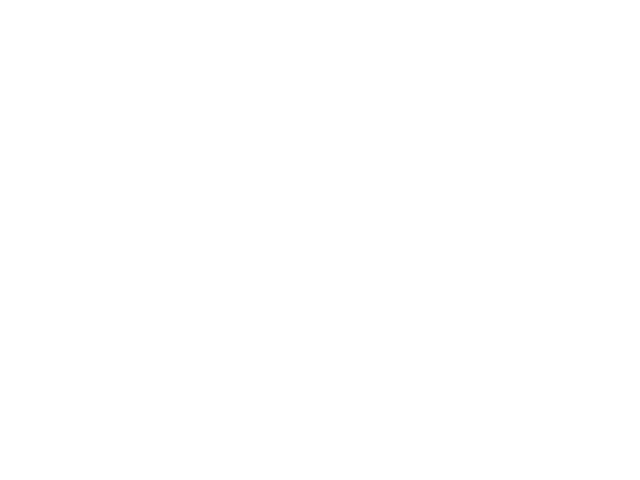

In [9]:
%matplotlib widget

colors = cmr.pride(np.linspace(0.1, 0.9, 8))

plot_peak_energy(peak)
plt.scatter(xs, ys, color=colors, marker="d", ec="#222222", s=81, lw=0.7)
plt.tight_layout()
plt.show()

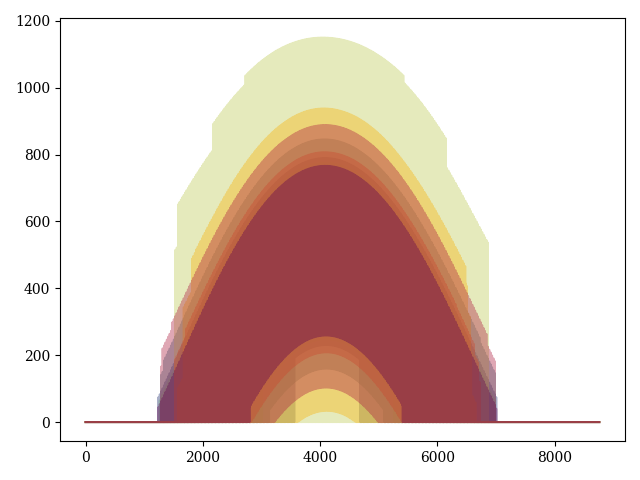

In [10]:
%matplotlib widget

fig, ax = plt.subplots()

i = 0
for x in np.arange(138, 138 * 9, 138):
    ax.plot(flux[:, x, x], color=colors[i], alpha=0.4)

    i += 1

# ax.set_yscale('log')

plt.tight_layout()
plt.show()

180.54688
187.76562
182.99219
197.98438
158.99219
97.75
87.61719
30.757812


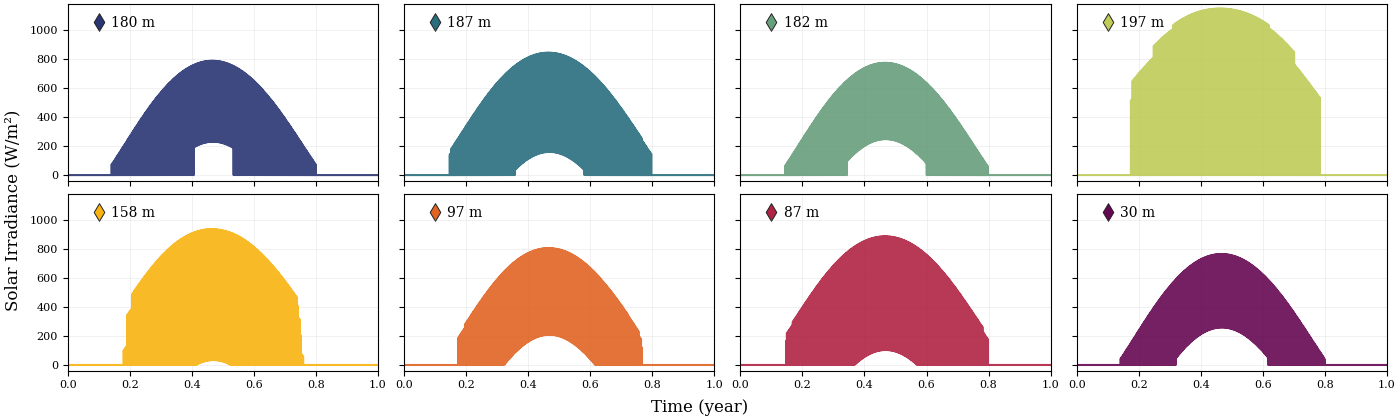

In [11]:
# Indices to sample along the diagonal
idxs = np.arange(138, 138 * 9, 138)[:8]

# Normalized time axis
t = np.linspace(0.0, 1.0, flux.shape[0], endpoint=False)

fig, axs = plt.subplots(2, 4, figsize=(14, 4.2), sharex=True, sharey=True, constrained_layout=True)
axes = axs.ravel()

for i, (ax, x) in enumerate(zip(axes, idxs)):
    # Plot the light-curve
    ax.plot(t, flux[:, x, x], color=colors[i % len(colors)], alpha=0.9, lw=1.5)
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(-40, 1180)
    ax.grid(alpha=0.2, linewidth=0.6)

    # Add a diamond marker in axes coords (0,1) = top-left corner
    ax.scatter(
        0.1, 0.9, transform=ax.transAxes, color=colors[i % len(colors)], marker="d", ec="#222222", s=81, lw=0.7, clip_on=False
    )
    ax.text(
        0.14, 0.87, f"{int(dem.values[x, x])} m", transform=ax.transAxes, 
    )

    print(dem.values[x, x])

# Optional: log scale
# for ax in axes: ax.set_yscale("log")

# Common labels
fig.supxlabel("Time (year)")
fig.supylabel("Solar Irradiance (W/m²)")

# Uniform tick label size (optional)
for ax in axes:
    ax.tick_params(labelsize=8)

plt.show()

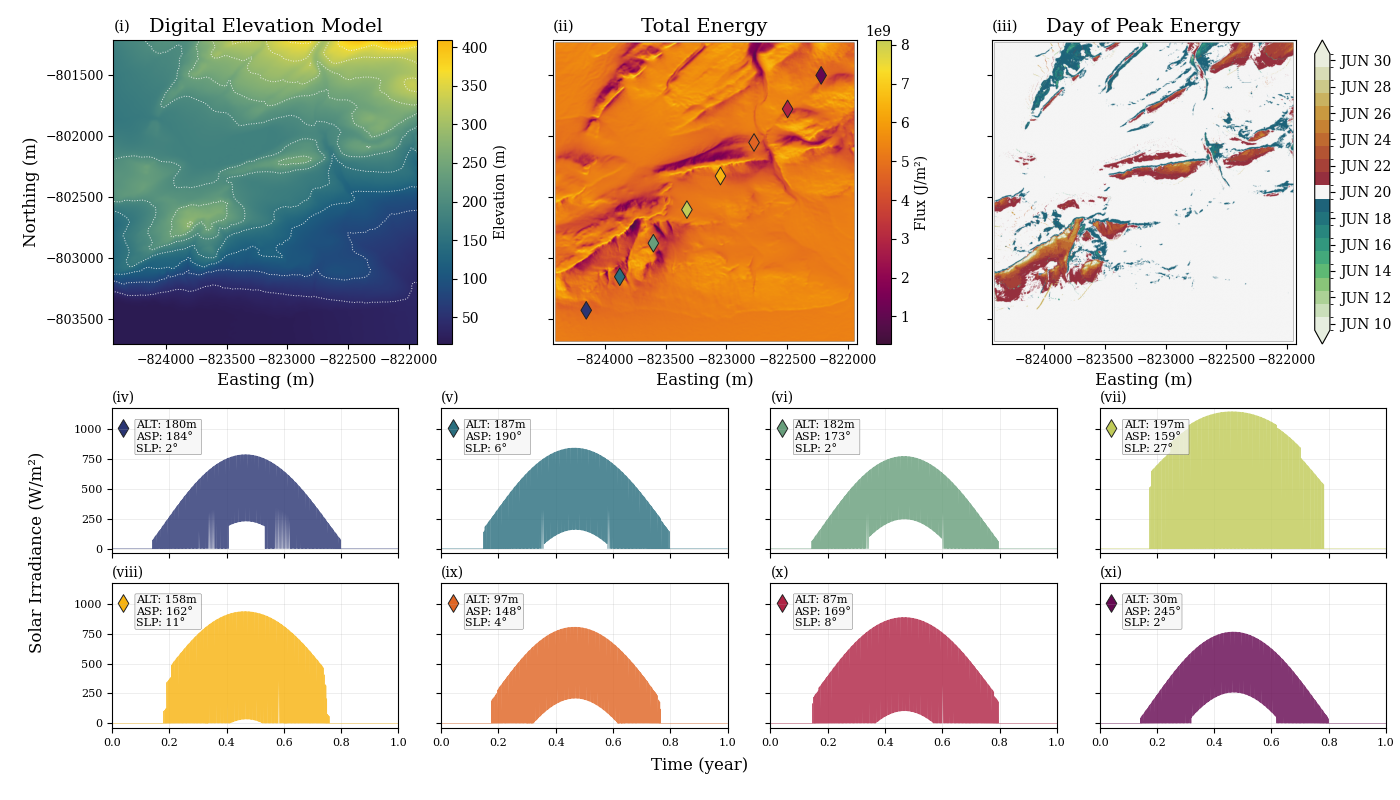

In [12]:
# --- figure + layout ---------------------------------------------------------
fig = plt.figure(figsize=(14, 8))

# Top row (3 panels across full width)
gs_top = GridSpec(1, 3, figure=fig, left=0.08, right=0.98, top=0.95, bottom=0.57, wspace=0.15)

# Bottom (2x4 grid across full width)
gs_bottom = GridSpec(2, 4, figure=fig, left=0.08, right=0.99, top=0.49, bottom=0.09, wspace=0.15, hspace=0.20)

# --- top row: three geospatial panels (share y) ------------------------------
ax_top = [fig.add_subplot(gs_top[0, i]) for i in range(3)]
for ax in ax_top[1:]:
    # hide just the labels
    ax.yaxis.set_major_formatter(NullFormatter())
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.tick_params(axis="y", which="both", labelleft=False)

# your plotters
plot_dem(dem, ax_top[0])
plot_total_energy(total, ax_top[1])
plot_day_of_peak(daypeak, daily_iso, sigma=9, ax=ax_top[2])

# titles/labels
titles = ["Digital Elevation Model", "Total Energy", "Day of Peak Energy"]
for ax, title in zip(ax_top, titles):
    ax.set_title(title, fontsize=14)
for ax in ax_top:
    ax.set_xlabel("Easting (m)", fontsize=12)
ax_top[0].set_ylabel("Northing (m)", fontsize=12)
for ax in ax_top:
    ax.tick_params(axis="both", labelsize=9)

# Remove y-labels for middle & right panels
ax_top[1].set_ylabel("")
ax_top[2].set_ylabel("")

# panel letters (a)–(c)
for lbl, ax in zip(["(i)", "(ii)", "(iii)"], ax_top):
    ax.text(0.0, 1.02, lbl, transform=ax.transAxes, ha="left", va="bottom", fontsize=11)

# --- overlay markers for sampled points on the middle map (optional) ---------
ny, nx = dem.shape
xmin, xmax, ymin, ymax = _get_extent(dem)
lin_diag = np.arange(138, 138 * 9, 138)
xs = xmin + (xmax - xmin) * (lin_diag + 0.5) / nx
ys = ymin + (ymax - ymin) * (lin_diag + 0.5) / ny

# pick your colors (already defined in your session)
ax_top[1].scatter(xs, ys, color=colors, marker="d", ec="#222222", s=81, lw=0.7)

# --- bottom 2x4 light-curve grid --------------------------------------------
idxs = lin_diag[:8]
t = np.linspace(0.0, 1.0, flux.shape[0], endpoint=False)

axes_bottom = [fig.add_subplot(gs_bottom[i, j]) for i in range(2) for j in range(4)]

for i, (ax, x) in enumerate(zip(axes_bottom, idxs)):
    ax.plot(t, flux[:, x, x], color=colors[i % len(colors)], alpha=0.81, lw=0.33)
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(-40, 1180)
    ax.grid(alpha=0.25, linewidth=0.6)
    # diamond marker at top-left (axes coords)
    ax.scatter(
        0.04,
        0.86,
        transform=ax.transAxes,
        clip_on=False,
        color=colors[i % len(colors)],
        marker="d",
        ec="#222222",
        s=81,
        lw=0.7,
    )
    ax.text(
        0.084, 0.7, f"ALT: {int(dem.values[x, x])}m \nASP: {int(aspect.values[x, x])}°\nSLP: {int(slope.values[x, x])}°", transform=ax.transAxes, fontsize=8,
        bbox=dict(facecolor="whitesmoke", edgecolor="#222", boxstyle="round,pad=0.1", alpha=0.7, lw=0.3)
    )

# hide interior tick labels
for i, ax in enumerate(axes_bottom):
    if i < 4:  # top row of bottom grid
        ax.set_xticklabels([])
    if i % 4 != 0:  # not first column
        ax.set_yticklabels([])
    ax.tick_params(labelsize=8)

# panel letters (d)–(k)
letters = ["(iv)", "(v)", "(vi)", "(vii)", "(viii)", "(ix)", "(x)", "(xi)"]
for lbl, ax in zip(letters, axes_bottom):
    ax.text(0.0, 1.02, lbl, transform=ax.transAxes, ha="left", va="bottom", fontsize=10)

# common labels for the bottom grid
fig.supxlabel("Time (year)", fontsize=12, y=0.033)
fig.supylabel("Solar Irradiance (W/m²)", fontsize=12, y=0.31)

# render/save
plt.savefig("solshade.pdf", bbox_inches="tight")
plt.show()